In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import SystemMessage, HumanMessage
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
from langchain_ollama import ChatOllama
evaluator_llm = ChatOllama(
    model = "phi4-mini:latest"
)

In [15]:
writer_llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.8
)
editor_llm = ChatMistralAI(
    model="mistral-large-latest",
    temperature=0.2
)

In [16]:
import operator
class PostState(TypedDict):
    topic: str 
    post: str 
    evaluation: Literal["approved" , "need_improvement"]
    feedback: str 
    iteration: int 
    max_iteration: int
    
    post_history: Annotated[list[str] , operator.add]
    feedback_history: Annotated[list[str] , operator.add]

In [18]:
def write_post(state: PostState):
    global writer_llm
    # define the prompt 
    messages = [
        SystemMessage(content = "You are a funny and clever Twitter/X influence."),
        HumanMessage(
            content = f"""Write a short, original, and hilarious post on the topic: {state['topic']}.
            Rules:
            - Do NOT use question-answer format.
            - Max 280 words.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english.
            - This is version {state['iteration'] + 1}.
            """
        )
    ]
    response = writer_llm.invoke(messages)
    return {
        "post": response.content,
        "post_history": [response.content]
    }

In [19]:
from pydantic import BaseModel, Field

class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "need_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the post.")

In [20]:
def evaluate_post(state: PostState):
    global evaluator_llm
    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate posts based on humor, originality, virality, and post format."),
        HumanMessage(content=f"""Evaluate the following post:\n
            post: "{state['post']}"
            Use the criteria below to evaluate the post:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people repost or share it?  
            5. Format – Is it a well-formed post (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """
        )
    ]
    structured_model = evaluator_llm.with_structured_output(PostEvaluation)
    response = structured_model.invoke(messages)
    return {
        "evaluation" : response.evaluation,
        "feedback": response.feedback,
        "feedback_history": [response.feedback]
    }

In [21]:
def optimize_post(state: PostState):
    global editor_llm
    messages = [
        SystemMessage(content="You punch up posts for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the post based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original post:
            {state['post']}

            Re-write it as a short, viral-worthy post. Avoid Q&A style and stay under 280 characters.
            """
        )
    ]
    response = editor_llm.invoke(messages)
    return {
        "post": response.content,
        "post_history": [response.content],
        "iteration": state["iteration"] + 1
    }
    

In [22]:
def route_evaluation(state: PostState):
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iteration']:
        return "approved"
    else:
        return "need_improvement"

In [23]:
graph = StateGraph(PostState)

graph.add_node("write_post" , write_post)
graph.add_node("evaluate_post" , evaluate_post)
graph.add_node("optimize_post" , optimize_post)

graph.add_edge(START , "write_post")
graph.add_edge("write_post" , "evaluate_post")
graph.add_conditional_edges(
    "evaluate_post" , route_evaluation , 
    {"approved": END , "need_improvement": "optimize_post"}
)
graph.add_edge("optimize_post" , "evaluate_post")
workflow = graph.compile()

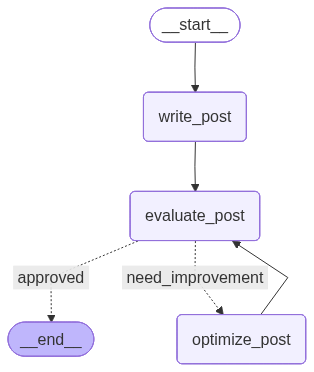

In [24]:
workflow

In [25]:
result = workflow.invoke({
    "topic": "LLM",
    "iteration": 0
})

In [26]:
print(result['post'])

**"LLMs are just really fancy autocomplete that got too confident and started charging rent.**

You ever type a text, hit send, then immediately regret it? That’s basically what’s happening when an LLM writes a 10-paragraph essay about why pineapple *does* belong on pizza. It doesn’t *know*—it’s just really good at guessing the next word like a drunk psychic at a carnival.

And don’t even get me started on the “hallucinations.” Oh, sorry, your AI just cited a study from *The Journal of Very Real Facts (2023)* that doesn’t exist. My uncle does the same thing at Thanksgiving, but at least he has the decency to blush.

We’ve all become prompt engineers now—typing increasingly desperate instructions like, *“Please write a haiku about my existential dread, but make it sound like a LinkedIn post.”* Meanwhile, the AI just sits there, judging us. *“Oh, you want me to do your job for you? How about I just write ‘lol’ and call it a day?”*

At this point, LLMs are less like robots and more like t